# Adaptación de dominio para detección de enfermedades en papa
## Pipeline VGG16 — Tres estrategias (MB · MA · MFT)

**Modelo base:** Transfer Learning con **VGG16** preentrenada en ImageNet  
**Dataset fuente:** PlantVillage (laboratorio, controlado)  
**Dataset objetivo:** Dataset Tanzano (campo real)  
**Clases:** `healthy` · `early_blight` · `late_blight`

| Sigla | Estrategia | Descripción |
|-------|------------|-------------|
| **MB** | Modelo Base | VGG16 entrenada solo con PlantVillage, sin aumento intensivo |
| **MA** | Aumento de datos | PlantVillage + data augmentation orientado a campo + fine-tuning parcial |
| **MFT** | Fine-tuning K-shot | Adaptar MA con pocas muestras reales de Tanzano |

> ⚠️ **Nota sobre VGG16:** a diferencia de EfficientNet, VGG16 **no normaliza internamente**.
> Las imágenes deben entregarse en rango `[0, 1]` usando `tf.keras.applications.vgg16.preprocess_input`
> (que centra por canal según ImageNet). Esto se aplica en el pipeline de datos.


## 0. Configuración de Kaggle y descarga del dataset


In [2]:
!mkdir -p ~/.kaggle
!echo KGAT_286aa34ec5b1c5ade37ee2d7717a6557 > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token
!pip install -q kaggle
!kaggle datasets download -d rizwan123456789/potato-disease-leaf-datasetpld
!unzip -q potato-disease-leaf-datasetpld.zip


Dataset URL: https://www.kaggle.com/datasets/rizwan123456789/potato-disease-leaf-datasetpld
License(s): DbCL-1.0
potato-disease-leaf-datasetpld.zip: Skipping, found more recently modified local copy (use --force to force download)


## 1. Verificación de GPU


In [3]:
import tensorflow as tf
print('TensorFlow version:', tf.__version__)

gpus = tf.config.list_physical_devices('GPU')
print('GPUs detectadas:', gpus)

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print('Memory growth activado para todas las GPUs.')
else:
    print('⚠️  No se detectó GPU. El entrenamiento será más lento en CPU.')

print('GPU disponible:', bool(gpus))


TensorFlow version: 2.21.0
GPUs detectadas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth activado para todas las GPUs.
GPU disponible: True


## 2. Importación de librerías


In [4]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')
print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.


## 3. Configuración inicial e hiperparámetros

> **VGG16 espera imágenes de 224×224 píxeles.** Usamos `vgg16_preprocess` que centra por canal
> según la media de ImageNet (en rango `[0, 255]` → centrado). No dividir entre 255 antes.


In [8]:
# ─── Tamaño de imagen ───────────────────────────────────────────────────────
# VGG16 fue entrenada con 224x224. Podría usarse 256x256 pero 224 es el estándar.
IMG_SIZE   = (224, 224)
IMG_SHAPE  = IMG_SIZE + (3,)
BATCH_SIZE = 16
SEED       = 42
NUM_CLASSES = 3

# ─── Épocas máximas por fase (EarlyStopping detiene antes si no mejora) ──────
MAX_EPOCHS_MB      = 100;  PATIENCE_MB      = 10
MAX_EPOCHS_MA_HEAD = 100;  PATIENCE_MA_HEAD = 10
MAX_EPOCHS_MA_FT   = 50;   PATIENCE_MA_FT   = 5
MAX_EPOCHS_MFT     = 50;   PATIENCE_MFT     = 5
EPOCHS_SANITY      = 30   # sanity check (sobreajuste sobre subconjunto pequeño)

# ─── K-shot: imágenes por clase de Tanzano para adaptar ──────────────────────
K_SHOT = 20  # cambiar a 5, 10, 50 para experimentar

# ─── Muestreo del dominio objetivo (None = usar todo) ────────────────────────
TARGET_SAMPLE_PER_CLASS = 600

# ─── Tasas de aprendizaje ─────────────────────────────────────────────────────
LR_HEAD = 1e-3   # entrenamiento del cabezal
LR_FT   = 1e-5   # fine-tuning parcial (MA fase 2)
LR_MFT  = 1e-5   # adaptación K-shot (MFT)

# ─── Class weight ─────────────────────────────────────────────────────────────
USE_CLASS_WEIGHT = False   # True = usar pesos suavizados (activar si hay colapso)
CLASS_WEIGHT_MAX = 2.0

AUTOTUNE = tf.data.AUTOTUNE

def set_seeds(seed=SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
set_seeds(SEED)

# ─── Detección de rutas del dataset ──────────────────────────────────────────
# El dataset PLD tiene estructura: PLD_3_Classes_256/{Training,Validation,Testing}
# PlantVillage y Tanzano se detectan automáticamente si están en el working dir
BASE_DIR   = Path('/home/robert/IA_TA')   # en Colab; ajustar si es local

# Rutas del dataset PLD (para MB/MA/MFT fuente)
SOURCE_ROOT = BASE_DIR / 'PLD_3_Classes_256'
PATH_TRAIN  = SOURCE_ROOT / 'Training'
PATH_VAL    = SOURCE_ROOT / 'Validation'
PATH_TEST   = SOURCE_ROOT / 'Testing'

# Ruta dataset Tanzano (dominio objetivo) — si existe
TARGET_DIR  = BASE_DIR / 'Dataset_Tanzano'

# Carpetas de salida
OUTPUTS_DIR = BASE_DIR / 'outputs'
MODELS_DIR  = OUTPUTS_DIR / 'models'
FIGURES_DIR = OUTPUTS_DIR / 'figures'
TABLES_DIR  = OUTPUTS_DIR / 'tables'
LOGS_DIR    = OUTPUTS_DIR / 'logs'
for d in [OUTPUTS_DIR, MODELS_DIR, FIGURES_DIR, TABLES_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Ruta base:', BASE_DIR)
print('Source (PLD):', SOURCE_ROOT, '| existe:', SOURCE_ROOT.exists())
print('Target (Tanzano):', TARGET_DIR, '| existe:', TARGET_DIR.exists())
print('Salidas en:', OUTPUTS_DIR)


Ruta base: /home/robert/IA_TA
Source (PLD): /home/robert/IA_TA/PLD_3_Classes_256 | existe: True
Target (Tanzano): /home/robert/IA_TA/Dataset_Tanzano | existe: False
Salidas en: /home/robert/IA_TA/outputs


## 4. Carga del dataset PLD con `image_dataset_from_directory`

Usamos la misma estructura de carpetas que el TA original. VGG16 recibe imágenes en
rango `[0, 255]` y luego `vgg16_preprocess` las centra internamente.


In [9]:
# Carga de los tres splits del dataset PLD
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    PATH_TRAIN,
    label_mode='int',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    PATH_VAL,
    label_mode='int',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    PATH_TEST,
    label_mode='int',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

CLASS_NAMES = train_ds_raw.class_names
print('Clases detectadas:', CLASS_NAMES)
print('NUM_CLASSES:', len(CLASS_NAMES))


Found 3251 files belonging to 3 classes.


I0000 00:00:1782147888.576595    5697 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 416 files belonging to 3 classes.
Found 405 files belonging to 3 classes.
Clases detectadas: ['Early_Blight', 'Healthy', 'Late_Blight']
NUM_CLASSES: 3


In [ ]:
set_seeds(SEED)

if TARGET_DIR.exists():
    print(f'Dataset Tanzano encontrado en {TARGET_DIR}')

    tanzano_ds_raw = tf.keras.utils.image_dataset_from_directory(
        TARGET_DIR,
        label_mode='int',
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    # Ignora archivos corruptos durante la lectura
    tanzano_ds_raw = tanzano_ds_raw.apply(tf.data.experimental.ignore_errors())

    total_images = 58709
    total_batches = total_images // BATCH_SIZE

    print("Batches aproximados:", total_batches)

    adapt_batches = total_batches // 2

    tanzano_adapt   = tanzano_ds_raw.take(adapt_batches)
    tanzano_test_ds = tanzano_ds_raw.skip(adapt_batches)

    kshot_batches = max(1, K_SHOT // BATCH_SIZE)

    target_kshot_ds = (
        tanzano_adapt
        .take(kshot_batches)
        .map(preprocess_vgg16, num_parallel_calls=AUTOTUNE)
        .prefetch(AUTOTUNE)
    )

    target_kval_ds = (
        tanzano_adapt
        .skip(kshot_batches)
        .take(kshot_batches)
        .map(preprocess_vgg16, num_parallel_calls=AUTOTUNE)
        .prefetch(AUTOTUNE)
    )

    target_test_ds = (
        tanzano_test_ds
        .map(preprocess_vgg16, num_parallel_calls=AUTOTUNE)
        .prefetch(AUTOTUNE)
    )

    print(f'K-shot adaptación: {kshot_batches} batches | validación MFT: {kshot_batches} batches')
    usar_tanzano = True

else:
    print(f'Dataset Tanzano NO encontrado en {TARGET_DIR}.')
    print('MFT se ejecutará sobre un subconjunto del test PLD (modo demostración).')

    kshot_batches = max(1, K_SHOT // BATCH_SIZE)

    target_kshot_ds = test_ds.take(kshot_batches)
    target_kval_ds  = test_ds.skip(kshot_batches).take(kshot_batches)
    target_test_ds  = test_ds

    usar_tanzano = False

print(f'Datasets K-shot listos. usar_tanzano={usar_tanzano}')

In [ ]:
# Función de preprocesamiento VGG16
# VGG16 requiere valores en [0,255] → preprocess_input los centra por canal (no divide entre 255).
def preprocess_vgg16(image, label):
    image = tf.cast(image, tf.float32)         # asegurar float32
    image = vgg16_preprocess(image)            # centra por canal ImageNet
    return image, label

# Aplicar preprocesamiento y optimizar con prefetch
train_ds = (train_ds_raw
            .map(preprocess_vgg16, num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))
val_ds   = (val_ds_raw
            .map(preprocess_vgg16, num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))
test_ds  = (test_ds_raw
            .map(preprocess_vgg16, num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))

# Verificación: rango de píxeles esperado para VGG16 (aprox. -120 a +150)
for xb, yb in train_ds.take(1):
    print('Batch shape:', xb.shape)
    print('Rango píxeles tras preprocess_input:', float(xb.numpy().min()), 'a', float(xb.numpy().max()))
    print('Etiquetas (primeras 8):', yb.numpy()[:8])
print('Pipeline PLD listo.')


target_test_ds = (tanzano_test_ds
                  .map(preprocess_vgg16, num_parallel_calls=AUTOTUNE)
                  .prefetch(AUTOTUNE))

Batch shape: (16, 224, 224, 3)
Rango píxeles tras preprocess_input: -123.68000030517578 a 151.06100463867188
Etiquetas (primeras 8): [0 0 0 2 2 0 2 2]
Pipeline PLD listo.


## 5. Visualización de imágenes de ejemplo


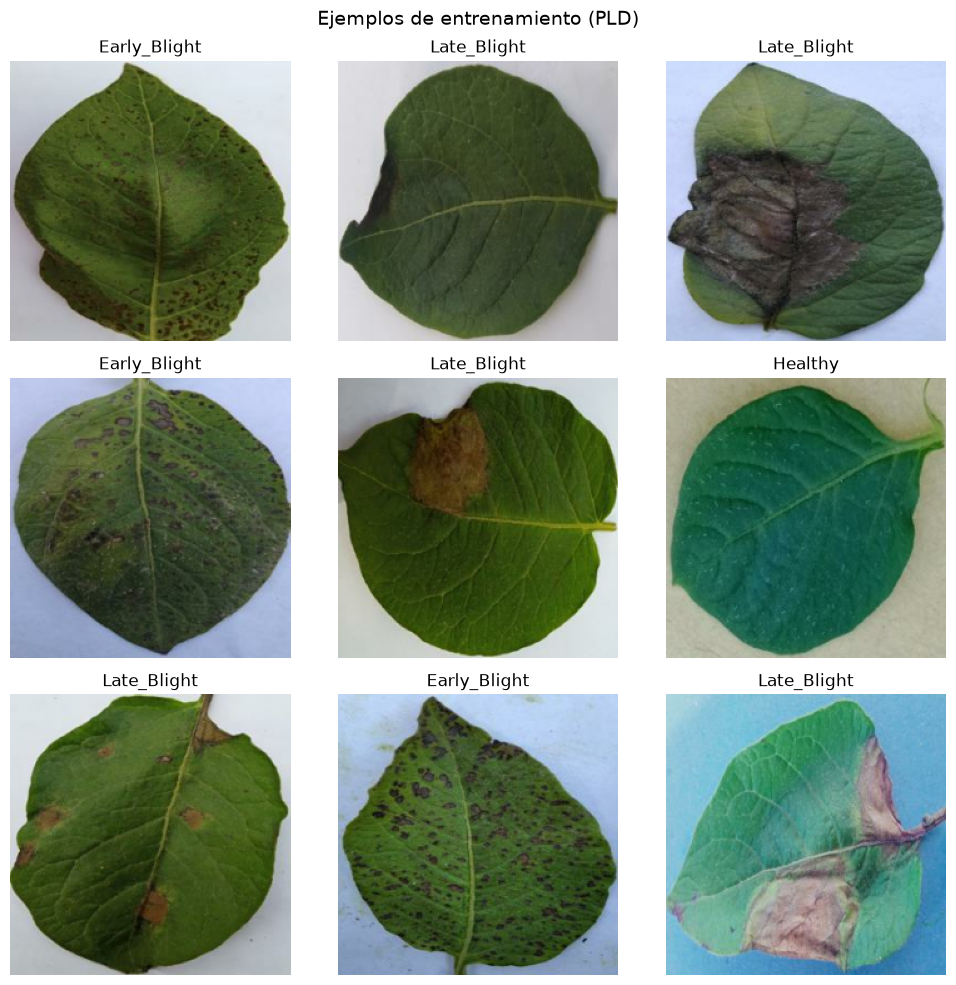

In [11]:
# Mostramos imágenes SIN preprocesamiento (rango original) para visualización correcta
plt.figure(figsize=(10, 10))
for images, labels in train_ds_raw.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(CLASS_NAMES[labels[i]])
        plt.axis('off')
plt.suptitle('Ejemplos de entrenamiento (PLD)', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ejemplos_pld.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Data augmentation

El augmentation opera **antes** del `preprocess_input`, sobre imágenes en rango `[0, 255]`.
Se integra dentro del modelo para activarse **solo en entrenamiento** automáticamente.


In [12]:
def build_augment_campo():
    """Aumento orientado a condiciones de campo (luz variable, ángulos, ruido)."""
    capas = [
        layers.RandomFlip('horizontal_and_vertical'),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.15),
    ]
    if hasattr(layers, 'RandomBrightness'):
        capas.append(layers.RandomBrightness(0.15, value_range=(0, 255)))
    capas.append(layers.GaussianNoise(0.03))   # ruido gaussiano nativo
    return models.Sequential(capas, name='augment_campo')

augment_base  = None                   # MB: sin aumento
augment_campo = build_augment_campo()  # MA: aumento moderado
print('Capas de augmentation MA:', [l.name for l in augment_campo.layers])


Capas de augmentation MA: ['random_flip', 'random_rotation', 'random_zoom', 'random_contrast', 'random_brightness', 'gaussian_noise']


## 7. Construcción del modelo VGG16

Arquitectura:
```
Input 224×224×3 (ya centrado por preprocess_input)
[Data augmentation — solo en training]
VGG16(include_top=False, weights='imagenet')   ← base congelada por defecto
GlobalAveragePooling2D
Dense(256, relu) → BatchNormalization → Dropout(0.3)
Dense(128, relu) → BatchNormalization → Dropout(0.2)
Dense(3, softmax)   ← clasificación final
```

> **Diferencia con EfficientNet:** VGG16 no tiene normalización interna. El `preprocess_input`
> que aplicamos en el pipeline de datos hace ese trabajo. Las capas de BN en el cabezal
> ayudan a estabilizar el entrenamiento.


In [13]:
def build_model_vgg16(augment=None, dropout1=0.3, dropout2=0.2,
                      dense1=256, dense2=128):
    """
    Construye el modelo VGG16 con cabezal de clasificación.
    Las imágenes de entrada ya vienen centradas por vgg16_preprocess.
    Devuelve (model, base_model).
    """
    inputs = layers.Input(shape=IMG_SHAPE, name='input_img')

    # Augmentation opcional (solo activo en training=True)
    x = augment(inputs) if augment is not None else inputs

    # Base VGG16 preentrenada (sin capas densas)
    base_model = VGG16(include_top=False, weights='imagenet', input_tensor=x)
    base_model.trainable = False   # base congelada por defecto

    # Cabezal de clasificación
    y = layers.GlobalAveragePooling2D(name='gap')(base_model.output)

    y = layers.Dense(dense1, activation='relu', name='dense_256')(y)
    y = layers.BatchNormalization(name='bn_1')(y)
    y = layers.Dropout(dropout1, name='dropout_1')(y)

    y = layers.Dense(dense2, activation='relu', name='dense_128')(y)
    y = layers.BatchNormalization(name='bn_2')(y)
    y = layers.Dropout(dropout2, name='dropout_2')(y)

    outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='salida')(y)

    model = models.Model(inputs, outputs, name='VGG16_transfer')
    return model, base_model


def compilar(model, lr):
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Demo del modelo
_demo, _ = build_model_vgg16(augment=None)
_demo.summary()
del _demo


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "VGG16_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_img (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           51

 Total params: 14,880,835 (56.77 MB)

 Trainable params: 165,379 (646.01 KB)

 Non-trainable params: 14,715,456 (56.14 MB)

## 8. Callbacks y funciones de evaluación


In [14]:
def make_callbacks(ckpt_name, patience, usar_val=True):
    """EarlyStopping + ReduceLROnPlateau + ModelCheckpoint del mejor modelo."""
    monitor = 'val_loss' if usar_val else 'loss'
    return [
        EarlyStopping(monitor=monitor, patience=patience,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor=monitor, factor=0.5,
                          patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint(filepath=str(MODELS_DIR / ckpt_name),
                        monitor=monitor, save_best_only=True, verbose=0),
    ]


def predecir(model, dataset):
    y_true, y_pred = [], []
    for xb, yb in dataset:
        probs = model.predict(xb, verbose=0)
        y_pred.extend(np.argmax(probs, axis=1))
        y_true.extend(yb.numpy())
    return np.array(y_true), np.array(y_pred)


def evaluate_model(model, dataset, class_names, nombre=''):
    y_true, y_pred = predecir(model, dataset)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f'\n=== Evaluación: {nombre} ===')
    print(f'  Accuracy={acc:.4f} | Precisión macro={prec:.4f} | Recall macro={rec:.4f} | F1 macro={f1:.4f}')
    print(classification_report(y_true, y_pred,
                                labels=list(range(len(class_names))),
                                target_names=class_names, zero_division=0))
    return {'nombre': nombre, 'accuracy': acc, 'precision_macro': prec,
            'recall_macro': rec, 'f1_macro': f1, 'y_true': y_true, 'y_pred': y_pred}


def diagnosticar_colapso(res, class_names, umbral=0.90):
    """Advierte si el modelo predice casi todo como una sola clase."""
    y_true, y_pred = res['y_true'], res['y_pred']
    real = pd.Series(y_true).value_counts().reindex(range(len(class_names)), fill_value=0)
    pred = pd.Series(y_pred).value_counts().reindex(range(len(class_names)), fill_value=0)
    print(f'\n--- Diagnóstico de colapso: {res["nombre"]} ---')
    print('  Clase         | reales | predichas')
    for i, c in enumerate(class_names):
        print(f'  {c:13s} | {int(real[i]):6d} | {int(pred[i]):6d}')
    frac_max = pred.max() / max(pred.sum(), 1)
    clase_dom = class_names[int(pred.idxmax())]
    if frac_max >= umbral:
        print(f'  *** ADVERTENCIA: posible COLAPSO → {frac_max*100:.1f}% en "{clase_dom}". ***')
        print('      Prueba: activar USE_CLASS_WEIGHT=True o reducir LR_HEAD.')
        return True
    print(f'  OK: predicciones repartidas (máximo {frac_max*100:.1f}% en "{clase_dom}").')
    return False


def plot_confusion_matrix(y_true, y_pred, class_names, titulo, fname):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    fig, ax = plt.subplots(figsize=(5, 4.2))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticks(range(len(class_names)))
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real'); ax.set_title(titulo)
    thr = cm.max() / 2 if cm.max() > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > thr else 'black')
    fig.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / fname, dpi=120, bbox_inches='tight')
    plt.show()


def plot_training_history(history, titulo, fname):
    h = history.history if hasattr(history, 'history') else history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(h.get('loss', []), label='train')
    if 'val_loss' in h: axes[0].plot(h['val_loss'], label='val')
    axes[0].set_title(f'Loss — {titulo}'); axes[0].set_xlabel('Época'); axes[0].legend()
    axes[1].plot(h.get('accuracy', []), label='train')
    if 'val_accuracy' in h: axes[1].plot(h['val_accuracy'], label='val')
    axes[1].set_title(f'Accuracy — {titulo}'); axes[1].set_xlabel('Época'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / fname, dpi=120, bbox_inches='tight')
    plt.show()


def guardar_historial(history, fname):
    h = history.history if hasattr(history, 'history') else history
    pd.DataFrame(h).to_csv(LOGS_DIR / fname, index=False)


def guardar_metricas(res_train, res_val, res_test, fname):
    filas = []
    for dominio, r in [('train', res_train), ('val', res_val), ('test', res_test)]:
        if r is None: continue
        filas.append({'dominio': dominio, 'accuracy': r['accuracy'],
                      'precision_macro': r['precision_macro'],
                      'recall_macro': r['recall_macro'], 'f1_macro': r['f1_macro']})
    pd.DataFrame(filas).to_csv(TABLES_DIR / fname, index=False)


print('Callbacks y funciones de evaluación definidas.')


Callbacks y funciones de evaluación definidas.


## 9. Sanity check — ¿el pipeline puede aprender?

Tomamos un subconjunto pequeño (1 batch) y verificamos que el modelo pueda sobreajustarlo.
Si la accuracy no sube por encima de 0.80, hay un problema en el preprocesamiento o las etiquetas.


W0000 00:00:1782147934.353465    6527 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1782147934.356215    6526 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
I0000 00:00:1782147934.364364    6212 service.cc:153] XLA service 0x71f7780375b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782147934.364392    6212 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.

Accuracy de entrenamiento tras 30 épocas: 0.9792
>> SANITY OK: el modelo SÍ puede aprender. El pipeline está correcto.


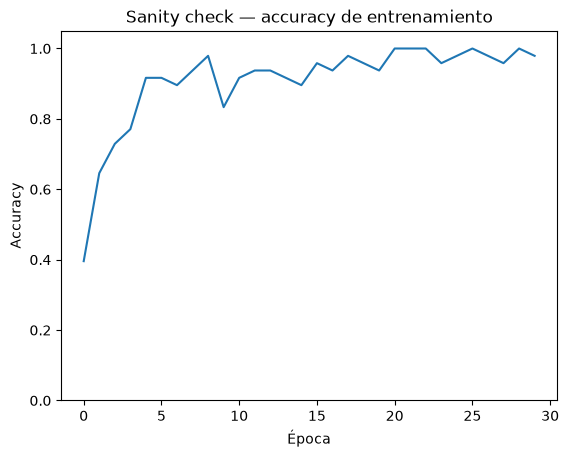

In [15]:
set_seeds(SEED)

# Tomar solo 1 batch para el sanity check
sanity_ds = train_ds.take(3)   # ~48 imágenes con batch_size=16

modelo_sanity, _ = build_model_vgg16(augment=None)
compilar(modelo_sanity, lr=LR_HEAD)

hist_sanity = modelo_sanity.fit(sanity_ds, epochs=EPOCHS_SANITY, verbose=0)

acc_final = hist_sanity.history['accuracy'][-1]
print(f'Accuracy de entrenamiento tras {EPOCHS_SANITY} épocas: {acc_final:.4f}')
if acc_final >= 0.80:
    print('>> SANITY OK: el modelo SÍ puede aprender. El pipeline está correcto.')
else:
    print('>> SANITY FALLA: el modelo NO logra sobreajustar.')
    print('   Revisa el preprocesamiento VGG16 (preprocess_input) y las etiquetas.')

plt.plot(hist_sanity.history['accuracy'])
plt.title('Sanity check — accuracy de entrenamiento')
plt.xlabel('Época'); plt.ylabel('Accuracy'); plt.ylim(0, 1.05)
plt.savefig(FIGURES_DIR / 'sanity_check.png', dpi=120, bbox_inches='tight')
plt.show()
del modelo_sanity


## 10. Manejo del desbalance de clases

Calculamos el `class_weight` suavizado (raíz cuadrada + recorte). Está **desactivado por defecto**;
activar `USE_CLASS_WEIGHT = True` en la sección de configuración si se observa colapso.


In [16]:
# Obtener etiquetas de todo el set de entrenamiento
y_train_all = np.concatenate([y.numpy() for _, y in train_ds_raw], axis=0)
clases_presentes = np.unique(y_train_all)

pesos_raw  = compute_class_weight('balanced', classes=clases_presentes, y=y_train_all)
class_weight_raw   = {int(c): float(w) for c, w in zip(clases_presentes, pesos_raw)}
pesos_suav = np.clip(np.sqrt(pesos_raw), None, CLASS_WEIGHT_MAX)
class_weight_suave = {int(c): float(w) for c, w in zip(clases_presentes, pesos_suav)}

print('class_weight RAW      :', {CLASS_NAMES[k]: round(v, 3) for k, v in class_weight_raw.items()})
print('class_weight SUAVIZADO:', {CLASS_NAMES[k]: round(v, 3) for k, v in class_weight_suave.items()})

class_weight_efectivo = class_weight_suave if USE_CLASS_WEIGHT else None
print('\nUSE_CLASS_WEIGHT =', USE_CLASS_WEIGHT, '->', 
      'se usa el suavizado' if USE_CLASS_WEIGHT else 'entrenamiento SIN class_weight')


class_weight RAW      : {'Early_Blight': 0.832, 'Healthy': 1.328, 'Late_Blight': 0.957}
class_weight SUAVIZADO: {'Early_Blight': 0.912, 'Healthy': 1.152, 'Late_Blight': 0.978}

USE_CLASS_WEIGHT = False -> entrenamiento SIN class_weight


## 11. Estrategia MB — Modelo Base

VGG16 + PlantVillage **sin aumento intensivo**. Base congelada, se entrena solo el cabezal.
EarlyStopping restaura los mejores pesos automáticamente.


>>> MB: entrenamiento del cabezal (base congelada)
Epoch 1/100


I0000 00:00:1782148194.839073    6212 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8253__.81


202/204 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7893 - loss: 0.5182

I0000 00:00:1782148207.289965    6213 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8253__.81


204/204 ━━━━━━━━━━━━━━━━━━━━ 21s 88ms/step - accuracy: 0.8662 - loss: 0.3565 - val_accuracy: 0.9471 - val_loss: 0.1417 - learning_rate: 0.0010
Epoch 2/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.9274 - loss: 0.2036 - val_accuracy: 0.9615 - val_loss: 0.1019 - learning_rate: 0.0010
Epoch 3/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - accuracy: 0.9425 - loss: 0.1547 - val_accuracy: 0.9519 - val_loss: 0.1147 - learning_rate: 0.0010
Epoch 4/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.9545 - loss: 0.1408 - val_accuracy: 0.9591 - val_loss: 0.0926 - learning_rate: 0.0010
Epoch 5/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.9514 - loss: 0.1333 - val_accuracy: 0.9423 - val_loss: 0.1657 - learning_rate: 0.0010
Epoch 6/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - accuracy: 0.9529 - loss: 0.1311 - val_accuracy: 0.9447 - val_loss: 0.1545 - learning_rate: 0.0010
Epoch 7/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.9486 - loss: 

...

203/204 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9719 - loss: 0.0876

W0000 00:00:1782148344.610972    9024 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


204/204 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - accuracy: 0.9745 - loss: 0.0796 - val_accuracy: 0.9639 - val_loss: 0.0838 - learning_rate: 5.0000e-04
Epoch 12/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 20s 61ms/step - accuracy: 0.9757 - loss: 0.0708 - val_accuracy: 0.9591 - val_loss: 0.1078 - learning_rate: 5.0000e-04
Epoch 13/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - accuracy: 0.9772 - loss: 0.0676 - val_accuracy: 0.9688 - val_loss: 0.0851 - learning_rate: 5.0000e-04
Epoch 14/100
203/204 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9802 - loss: 0.0676
Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
204/204 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - accuracy: 0.9812 - loss: 0.0580 - val_accuracy: 0.9639 - val_loss: 0.0969 - learning_rate: 5.0000e-04
Epoch 15/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - accuracy: 0.9769 - loss: 0.0611 - val_accuracy: 0.9688 - val_loss: 0.0811 - learning_rate: 2.5000e-04
Epoch 16/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - ac

W0000 00:00:1782148464.785332    9024 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


204/204 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.9831 - loss: 0.0515 - val_accuracy: 0.9688 - val_loss: 0.0743 - learning_rate: 1.2500e-04
Epoch 21/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.9843 - loss: 0.0457 - val_accuracy: 0.9712 - val_loss: 0.0700 - learning_rate: 1.2500e-04
Epoch 22/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.9892 - loss: 0.0346 - val_accuracy: 0.9712 - val_loss: 0.0702 - learning_rate: 1.2500e-04
Epoch 23/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - accuracy: 0.9825 - loss: 0.0420 - val_accuracy: 0.9688 - val_loss: 0.0782 - learning_rate: 1.2500e-04
Epoch 24/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9862 - loss: 0.0391
Epoch 24: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
204/204 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - accuracy: 0.9859 - loss: 0.0419 - val_accuracy: 0.9712 - val_loss: 0.0724 - learning_rate: 1.2500e-04
Epoch 25/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - acc

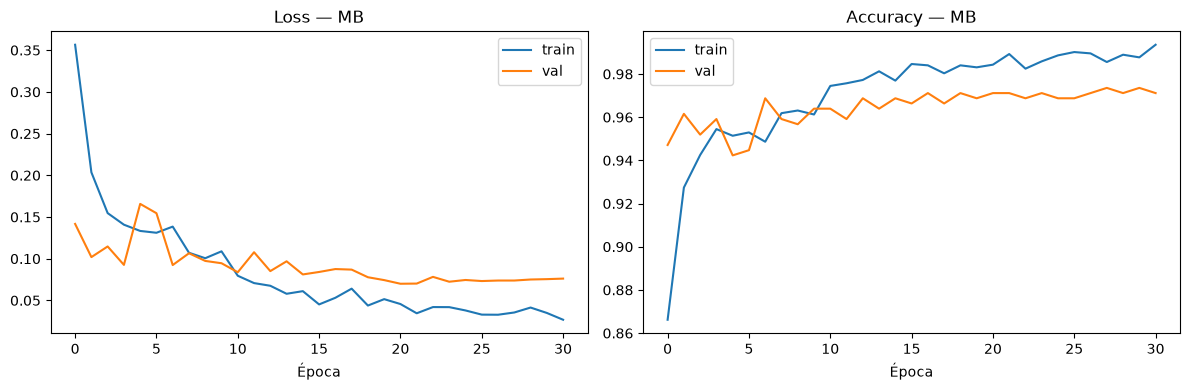

In [17]:
set_seeds(SEED)
modelo_MB, base_MB = build_model_vgg16(augment=augment_base)
compilar(modelo_MB, lr=LR_HEAD)

print('>>> MB: entrenamiento del cabezal (base congelada)')
hist_MB = modelo_MB.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS_MB,
    class_weight=class_weight_efectivo,
    callbacks=make_callbacks('modelo_MB_best.keras', PATIENCE_MB),
    verbose=1
)

plot_training_history(hist_MB, 'MB', 'curvas_MB.png')
guardar_historial(hist_MB, 'historial_MB.csv')



=== Evaluación: MB - train ===
  Accuracy=0.9991 | Precisión macro=0.9989 | Recall macro=0.9990 | F1 macro=0.9990
              precision    recall  f1-score   support

Early_Blight       1.00      1.00      1.00      1303
     Healthy       1.00      1.00      1.00       816
 Late_Blight       1.00      1.00      1.00      1132

    accuracy                           1.00      3251
   macro avg       1.00      1.00      1.00      3251
weighted avg       1.00      1.00      1.00      3251


=== Evaluación: MB - val ===
  Accuracy=0.9712 | Precisión macro=0.9709 | Recall macro=0.9687 | F1 macro=0.9698
              precision    recall  f1-score   support

Early_Blight       0.98      0.98      0.98       163
     Healthy       0.97      0.95      0.96       102
 Late_Blight       0.97      0.97      0.97       151

    accuracy                           0.97       416
   macro avg       0.97      0.97      0.97       416
weighted avg       0.97      0.97      0.97       416


=== Evalu

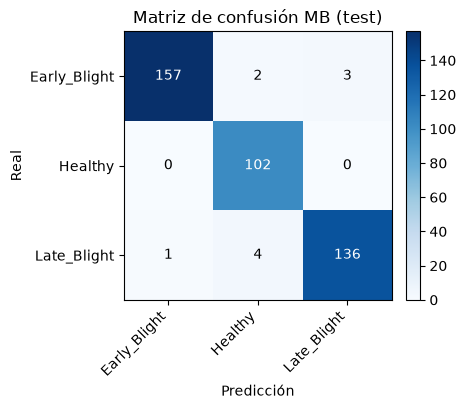


MB guardado en outputs/models/modelo_MB.keras


In [ ]:
# Evaluación MB
res_MB_train = evaluate_model(modelo_MB, train_ds, CLASS_NAMES, 'MB - train')
res_MB_val   = evaluate_model(modelo_MB, val_ds,   CLASS_NAMES, 'MB - val')
res_MB_test  = evaluate_model(modelo_MB, target_test_ds, CLASS_NAMES, 'MB - Tanzano')
diagnosticar_colapso(res_MB_test, CLASS_NAMES)

plot_confusion_matrix(res_MB_test['y_true'], res_MB_test['y_pred'],
                      CLASS_NAMES, 'Matriz de confusión MB (test)', 'matriz_confusion_MB.png')
modelo_MB.save(MODELS_DIR / 'modelo_MB.keras')
guardar_metricas(res_MB_train, res_MB_val, res_MB_test, 'metricas_MB.csv')
print('\nMB guardado en outputs/models/modelo_MB.keras')


## 12. Estrategia MA — Aumento de datos + Fine-tuning parcial

* **Fase 1:** base congelada, entrenar cabezal con augmentation orientado a campo.  
* **Fase 2:** descongelar el último ~20 % de capas de VGG16 (bloque conv5), `BatchNorm` congelado,
  recompilar con `lr=1e-5`.

> En VGG16 el último bloque convolucional (`block5`) son las capas más especializadas.
> Descongelarlas permite adaptar los filtros al dominio agrícola sin perder los rasgos generales.


In [19]:
set_seeds(SEED)
modelo_MA, base_MA = build_model_vgg16(augment=augment_campo)
compilar(modelo_MA, lr=LR_HEAD)

print('>>> MA Fase 1: entrenamiento del cabezal con augmentation')
hist_MA1 = modelo_MA.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS_MA_HEAD,
    class_weight=class_weight_efectivo,
    callbacks=make_callbacks('modelo_MA_f1_best.keras', PATIENCE_MA_HEAD),
    verbose=1
)


>>> MA Fase 1: entrenamiento del cabezal con augmentation
Epoch 1/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 23s 90ms/step - accuracy: 0.6017 - loss: 0.9566 - val_accuracy: 0.6010 - val_loss: 0.9828 - learning_rate: 0.0010
Epoch 2/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - accuracy: 0.6853 - loss: 0.7356 - val_accuracy: 0.7788 - val_loss: 0.6065 - learning_rate: 0.0010
Epoch 3/100
  2/204 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - accuracy: 0.6094 - loss: 0.8186 

W0000 00:00:1782148864.447443   21947 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - accuracy: 0.6936 - loss: 0.7171 - val_accuracy: 0.6947 - val_loss: 0.9078 - learning_rate: 0.0010
Epoch 4/100
  2/204 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.8594 - loss: 0.5539 

W0000 00:00:1782148881.306991   21947 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - accuracy: 0.7072 - loss: 0.6849 - val_accuracy: 0.7692 - val_loss: 0.6093 - learning_rate: 0.0010
Epoch 5/100
203/204 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.7356 - loss: 0.6360

W0000 00:00:1782148914.432443   22180 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size



Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
204/204 ━━━━━━━━━━━━━━━━━━━━ 18s 87ms/step - accuracy: 0.7376 - loss: 0.6271 - val_accuracy: 0.7596 - val_loss: 0.6451 - learning_rate: 0.0010
Epoch 6/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 18s 86ms/step - accuracy: 0.7259 - loss: 0.6381 - val_accuracy: 0.6923 - val_loss: 1.1320 - learning_rate: 5.0000e-04
Epoch 7/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - accuracy: 0.7425 - loss: 0.6117 - val_accuracy: 0.7067 - val_loss: 0.9618 - learning_rate: 5.0000e-04
Epoch 8/100
203/204 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.7555 - loss: 0.5967
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
204/204 ━━━━━━━━━━━━━━━━━━━━ 18s 87ms/step - accuracy: 0.7542 - loss: 0.5985 - val_accuracy: 0.6947 - val_loss: 0.9190 - learning_rate: 5.0000e-04
Epoch 9/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - accuracy: 0.7564 - loss: 0.5797 - val_accuracy: 0.6947 - val_loss: 1.0884 - learning_rate: 2.5

W0000 00:00:1782149001.567957   22180 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - accuracy: 0.7711 - loss: 0.5685 - val_accuracy: 0.7067 - val_loss: 1.1182 - learning_rate: 2.5000e-04
Epoch 11/100
203/204 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.7456 - loss: 0.5845
Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - accuracy: 0.7570 - loss: 0.5665 - val_accuracy: 0.6899 - val_loss: 1.3112 - learning_rate: 2.5000e-04
Epoch 12/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - accuracy: 0.7567 - loss: 0.5785 - val_accuracy: 0.7260 - val_loss: 0.9927 - learning_rate: 1.2500e-04
Epoch 12: early stopping
Restoring model weights from the end of the best epoch: 2.


In [20]:
print('>>> MA Fase 2: fine-tuning parcial (último ~20% de capas de VGG16, BatchNorm congelado)')

def descongelar_ultimo_porcentaje(base_model, pct=0.20):
    """Descongela el último `pct` de capas de la base (BatchNorm siempre congelado)."""
    base_model.trainable = True
    n = len(base_model.layers)
    corte = int(n * (1 - pct))
    for i, capa in enumerate(base_model.layers):
        if isinstance(capa, layers.BatchNormalization):
            capa.trainable = False   # BN siempre congelado en fine-tuning
        else:
            capa.trainable = i >= corte
    n_train = sum(c.trainable for c in base_model.layers)
    print(f'  Capas entrenables en base_MA: {n_train}/{n} (desde capa {corte})')

descongelar_ultimo_porcentaje(base_MA, pct=0.20)
compilar(modelo_MA, lr=LR_FT)   # recompilar tras cambiar trainable

hist_MA2 = modelo_MA.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS_MA_FT,
    class_weight=class_weight_efectivo,
    callbacks=make_callbacks('modelo_MA_best.keras', PATIENCE_MA_FT),
    verbose=1
)


>>> MA Fase 2: fine-tuning parcial (último ~20% de capas de VGG16, BatchNorm congelado)
  Capas entrenables en base_MA: 4/20 (desde capa 16)
Epoch 1/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - accuracy: 0.7213 - loss: 0.6729 - val_accuracy: 0.8293 - val_loss: 0.5065 - learning_rate: 1.0000e-05
Epoch 2/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 18s 86ms/step - accuracy: 0.7330 - loss: 0.6321 - val_accuracy: 0.8269 - val_loss: 0.4615 - learning_rate: 1.0000e-05
Epoch 3/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 18s 86ms/step - accuracy: 0.7558 - loss: 0.5849 - val_accuracy: 0.8510 - val_loss: 0.4515 - learning_rate: 1.0000e-05
Epoch 4/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - accuracy: 0.7585 - loss: 0.5902 - val_accuracy: 0.8365 - val_loss: 0.5667 - learning_rate: 1.0000e-05
Epoch 5/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - accuracy: 0.7742 - loss: 0.5532 - val_accuracy: 0.8486 - val_loss: 0.4614 - learning_rate: 1.0000e-05
Epoch 6/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 18s 86ms/step - accuracy: 0.7

W0000 00:00:1782149271.662925   23707 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - accuracy: 0.8081 - loss: 0.4692 - val_accuracy: 0.9159 - val_loss: 0.2311 - learning_rate: 1.0000e-05
Epoch 13/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - accuracy: 0.8124 - loss: 0.4630 - val_accuracy: 0.9399 - val_loss: 0.1708 - learning_rate: 1.0000e-05
Epoch 14/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - accuracy: 0.8308 - loss: 0.4474 - val_accuracy: 0.9543 - val_loss: 0.1647 - learning_rate: 1.0000e-05
Epoch 15/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - accuracy: 0.8213 - loss: 0.4428 - val_accuracy: 0.9351 - val_loss: 0.1734 - learning_rate: 1.0000e-05
Epoch 16/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - accuracy: 0.8176 - loss: 0.4532 - val_accuracy: 0.9495 - val_loss: 0.1487 - learning_rate: 1.0000e-05
Epoch 17/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - accuracy: 0.8308 - loss: 0.4250 - val_accuracy: 0.9399 - val_loss: 0.1497 - learning_rate: 1.0000e-05
Epoch 18/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - a

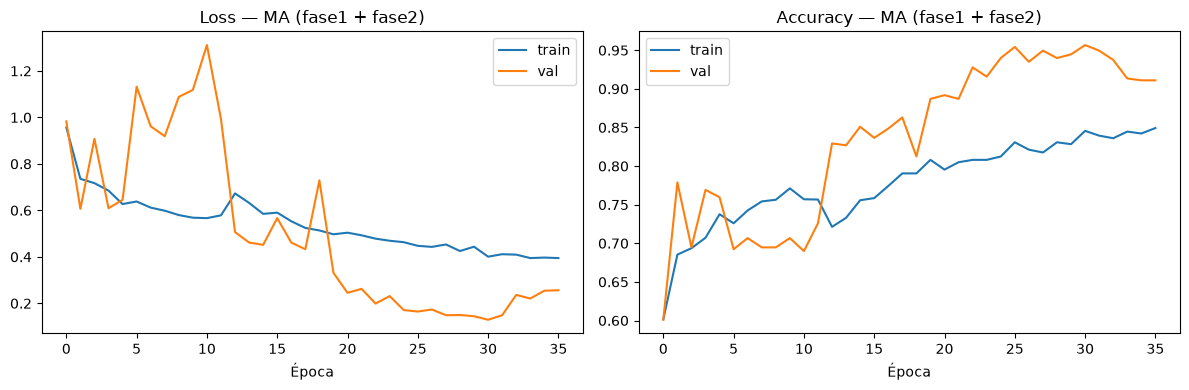


=== Evaluación: MA - train ===
  Accuracy=0.9520 | Precisión macro=0.9503 | Recall macro=0.9478 | F1 macro=0.9488
              precision    recall  f1-score   support

Early_Blight       0.97      0.96      0.96      1303
     Healthy       0.94      0.91      0.93       816
 Late_Blight       0.94      0.98      0.96      1132

    accuracy                           0.95      3251
   macro avg       0.95      0.95      0.95      3251
weighted avg       0.95      0.95      0.95      3251


=== Evaluación: MA - val ===
  Accuracy=0.9567 | Precisión macro=0.9557 | Recall macro=0.9520 | F1 macro=0.9535
              precision    recall  f1-score   support

Early_Blight       0.97      0.95      0.96       163
     Healthy       0.95      0.91      0.93       102
 Late_Blight       0.94      0.99      0.97       151

    accuracy                           0.96       416
   macro avg       0.96      0.95      0.95       416
weighted avg       0.96      0.96      0.96       416


=== Evalu

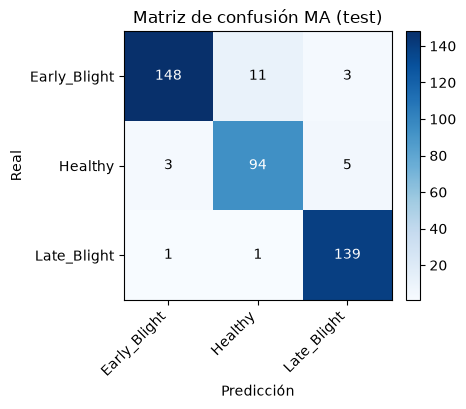


MA guardado en outputs/models/modelo_MA.keras


In [ ]:
# Historial combinado fase 1 + fase 2
hist_MA_comb = {k: list(hist_MA1.history.get(k, [])) + list(hist_MA2.history.get(k, []))
                for k in set(hist_MA1.history) | set(hist_MA2.history)}
plot_training_history(hist_MA_comb, 'MA (fase1 + fase2)', 'curvas_MA.png')
guardar_historial(hist_MA_comb, 'historial_MA.csv')

# Evaluación MA
res_MA_train = evaluate_model(modelo_MA, train_ds, CLASS_NAMES, 'MA - train')
res_MA_val   = evaluate_model(modelo_MA, val_ds,   CLASS_NAMES, 'MA - val')
res_MA_test  = evaluate_model(modelo_MA, target_test_ds, CLASS_NAMES, 'MA - Tanzano')
diagnosticar_colapso(res_MA_train, CLASS_NAMES)
colapso_MA = diagnosticar_colapso(res_MA_test, CLASS_NAMES)

plot_confusion_matrix(res_MA_test['y_true'], res_MA_test['y_pred'],
                      CLASS_NAMES, 'Matriz de confusión MA (test)', 'matriz_confusion_MA.png')
modelo_MA.save(MODELS_DIR / 'modelo_MA.keras')
guardar_metricas(res_MA_train, res_MA_val, res_MA_test, 'metricas_MA.csv')
print('\nMA guardado en outputs/models/modelo_MA.keras')


## 13. Estrategia MFT — Fine-tuning K-shot con dominio objetivo (Tanzano)

Si el dataset Tanzano está disponible, tomamos K imágenes por clase y adaptamos el modelo MA.
Si no está disponible, aplicamos MFT sobre un subconjunto del dataset PLD a modo de demostración.

> **Sin fuga de datos:** el conjunto de test nunca se usa para adaptar el modelo.


Dataset Tanzano encontrado en /home/robert/IA_TA/Dataset_Tanzano
Found 58709 files belonging to 3 classes.
Batches aproximados: 3669
K-shot adaptación: 1 batches | validación MFT: 1 batches
Datasets K-shot listos. usar_tanzano=True


Modelo MA cargado desde disco para MFT.
>>> MFT: adaptación K-shot con K=20 imágenes/clase
Epoch 1/50
      1/Unknown 2s 2s/step - accuracy: 0.9375 - loss: 0.2265

I0000 00:00:1782151148.363040  306369 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 7026412369630689281
I0000 00:00:1782151148.363078  306369 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 8856721099472977911
I0000 00:00:1782151148.363083  306369 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 6240986231689766868


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.9375 - loss: 0.2265 - val_accuracy: 0.8750 - val_loss: 1.9566 - learning_rate: 1.0000e-05
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.6875 - loss: 0.5935 - val_accuracy: 0.6250 - val_loss: 4.2477 - learning_rate: 1.0000e-05
Epoch 3/50


I0000 00:00:1782151148.890480  306339 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 14557263295523158262
I0000 00:00:1782151148.890525  306339 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 4878989977856942466
I0000 00:00:1782151148.890530  306339 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 10246512413890667328
I0000 00:00:1782151148.998635  306369 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 7026412369630689281
I0000 00:00:1782151148.998677  306369 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 8856721099472977911
I0000 00:00:1782151148.998683  306369 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 6240986231689766868


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.6875 - loss: 0.8445

...

I0000 00:00:1782151152.928972  306369 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 7026412369630689281
I0000 00:00:1782151152.929020  306369 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 8856721099472977911
I0000 00:00:1782151152.929028  306369 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 6240986231689766868


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.8125 - loss: 0.6177 - val_accuracy: 0.9375 - val_loss: 0.2801 - learning_rate: 2.5000e-06
Epoch 16/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9375 - loss: 0.3769

I0000 00:00:1782151153.131623  306369 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 7026412369630689281
I0000 00:00:1782151153.131660  306369 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 8856721099472977911
I0000 00:00:1782151153.131668  306369 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 6240986231689766868


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9375 - loss: 0.3769 - val_accuracy: 0.8125 - val_loss: 0.9361 - learning_rate: 2.5000e-06
Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 11.


I0000 00:00:1782151153.340819  306369 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 8856721099472977911
I0000 00:00:1782151153.340852  306369 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 6240986231689766868


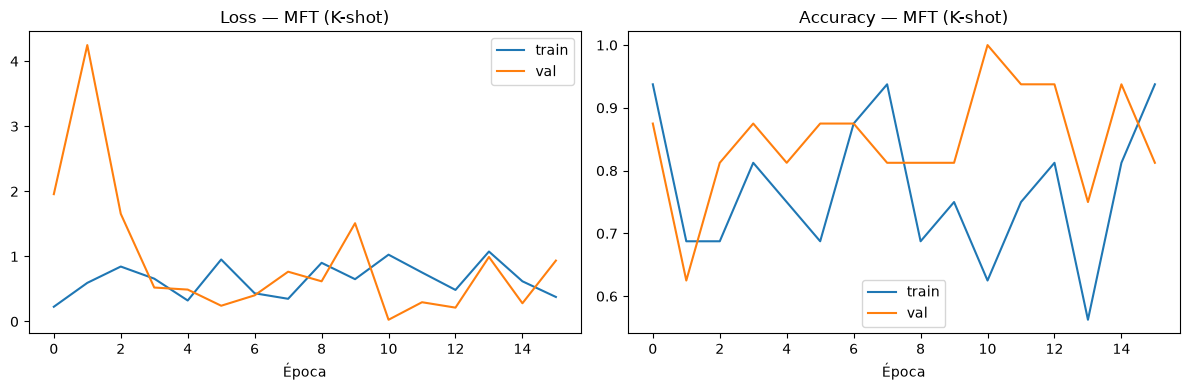

In [32]:
if colapso_MA:
    print('*** MA colapsó en test. MFT no se ejecuta automáticamente. ***')
    print('    Activa USE_CLASS_WEIGHT=True o reduce LR_HEAD y vuelve a entrenar MA.')
    res_MFT_test = None
else:
    # Cargar el mejor modelo MA guardado (sin capas personalizadas → seguro)
    try:
        modelo_MFT = tf.keras.models.load_model(MODELS_DIR / 'modelo_MA.keras')
        print('Modelo MA cargado desde disco para MFT.')
    except Exception as e:
        print(f'No se pudo cargar desde disco ({e}). Clonando MA en memoria.')
        modelo_MFT = tf.keras.models.clone_model(modelo_MA)
        modelo_MFT.set_weights(modelo_MA.get_weights())

    compilar(modelo_MFT, lr=LR_MFT)
    print(f'>>> MFT: adaptación K-shot con K={K_SHOT} imágenes/clase')

    hist_MFT = modelo_MFT.fit(
        target_kshot_ds,
        validation_data=target_kval_ds,
        epochs=MAX_EPOCHS_MFT,
        callbacks=make_callbacks('modelo_MFT_best.keras', PATIENCE_MFT),
        verbose=1
    )
    plot_training_history(hist_MFT, 'MFT (K-shot)', 'curvas_MFT.png')
    guardar_historial(hist_MFT, 'historial_MFT.csv')


Mejor modelo MFT cargado desde checkpoint.


E0000 00:00:1782151195.600535  307013 jpeg_mem.cc:331] Premature end of JPEG data. Stopped at line 734/1000
E0000 00:00:1782151330.737259  307021 jpeg_mem.cc:331] Premature end of JPEG data. Stopped at line 558/750



=== Evaluación: MFT - test ===
  Accuracy=0.7763 | Precisión macro=0.8170 | Recall macro=0.7580 | F1 macro=0.7386
              precision    recall  f1-score   support

Early_Blight       0.90      0.35      0.51      8885
     Healthy       0.89      0.99      0.93     10184
 Late_Blight       0.66      0.93      0.77     10232

    accuracy                           0.78     29301
   macro avg       0.82      0.76      0.74     29301
weighted avg       0.81      0.78      0.75     29301


--- Diagnóstico de colapso: MFT - test ---
  Clase         | reales | predichas
  Early_Blight  |   8885 |   3476
  Healthy       |  10184 |  11312
  Late_Blight   |  10232 |  14513
  OK: predicciones repartidas (máximo 49.5% en "Late_Blight").


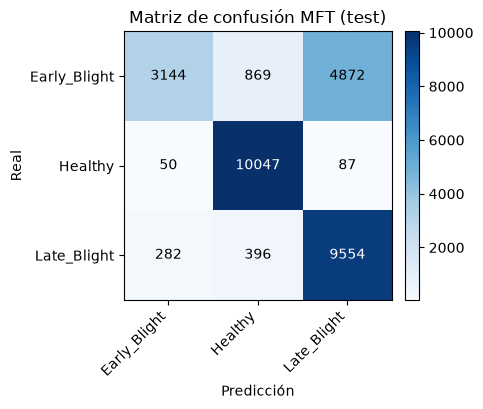


MFT guardado en outputs/models/modelo_MFT.keras


In [ ]:
if colapso_MA:
    print('MFT omitido. No hay métricas MFT en esta corrida.')
    res_MFT_test = None
else:
    best_mft_path = MODELS_DIR / 'modelo_MFT_best.keras'
    if best_mft_path.exists():
        modelo_MFT = tf.keras.models.load_model(best_mft_path)
        print('Mejor modelo MFT cargado desde checkpoint.')

    res_MFT_test = evaluate_model(modelo_MFT, target_test_ds, CLASS_NAMES, 'MFT - Tanzano')
    diagnosticar_colapso(res_MFT_test, CLASS_NAMES)

    plot_confusion_matrix(
        res_MFT_test['y_true'], res_MFT_test['y_pred'],
        CLASS_NAMES, 'Matriz de confusión MFT (test)', 'matriz_confusion_MFT.png'
    )
    modelo_MFT.save(MODELS_DIR / 'modelo_MFT.keras')
    guardar_metricas(None, None, res_MFT_test, 'metricas_MFT.csv')
    print('\nMFT guardado en outputs/models/modelo_MFT.keras')


## 14. Evaluación comparativa final


In [34]:
filas = [
    {'Modelo': 'MB', 'Accuracy test': res_MB_test['accuracy'],
     'Precisión macro': res_MB_test['precision_macro'],
     'Recall macro': res_MB_test['recall_macro'], 'F1 macro': res_MB_test['f1_macro']},
    {'Modelo': 'MA', 'Accuracy test': res_MA_test['accuracy'],
     'Precisión macro': res_MA_test['precision_macro'],
     'Recall macro': res_MA_test['recall_macro'], 'F1 macro': res_MA_test['f1_macro']},
]
if res_MFT_test is not None:
    filas.append({'Modelo': 'MFT', 'Accuracy test': res_MFT_test['accuracy'],
                  'Precisión macro': res_MFT_test['precision_macro'],
                  'Recall macro': res_MFT_test['recall_macro'],
                  'F1 macro': res_MFT_test['f1_macro']})

comparativa = pd.DataFrame(filas).round(4)
comparativa.to_csv(TABLES_DIR / 'comparativa_final.csv', index=False)
print('Tabla comparativa:')
print(comparativa.to_string(index=False))


Tabla comparativa:
Modelo  Accuracy test  Precisión macro  Recall macro  F1 macro
    MB         0.9753           0.9722        0.9779    0.9747
    MA         0.9407           0.9354        0.9403    0.9373
   MFT         0.7763           0.8170        0.7580    0.7386


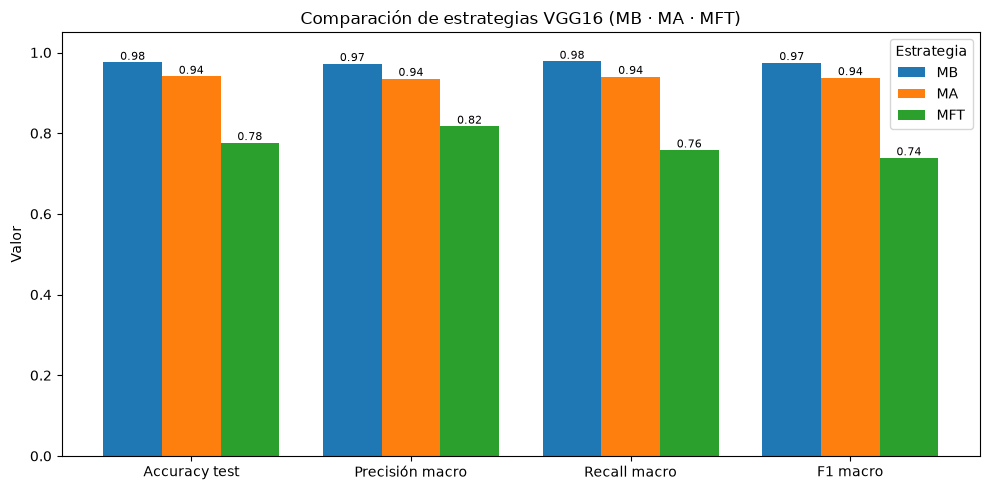

In [35]:
metricas  = ['Accuracy test', 'Precisión macro', 'Recall macro', 'F1 macro']
modelos_l = list(comparativa['Modelo'])
x = np.arange(len(metricas)); ancho = 0.8 / len(modelos_l)

fig, ax = plt.subplots(figsize=(10, 5))
for i, modelo in enumerate(modelos_l):
    vals = comparativa[comparativa['Modelo'] == modelo][metricas].values.flatten()
    barras = ax.bar(x + (i - (len(modelos_l)-1)/2) * ancho, vals, ancho, label=modelo)
    for b, v in zip(barras, vals):
        ax.text(b.get_x() + b.get_width()/2, v, f'{v:.2f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.05); ax.set_ylabel('Valor')
ax.set_title('Comparación de estrategias VGG16 (MB · MA · MFT)')
ax.legend(title='Estrategia')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'comparativa_final.png', dpi=120, bbox_inches='tight')
plt.show()


## 15. Conclusiones automáticas


In [36]:
acc_mb  = res_MB_test['accuracy']
acc_ma  = res_MA_test['accuracy']
acc_mft = res_MFT_test['accuracy'] if res_MFT_test is not None else None

L = ['CONCLUSIONES AUTOMÁTICAS DEL EXPERIMENTO (VGG16)', '=' * 55]
L.append(f'- MB  accuracy test: {acc_mb:.4f}  | F1 macro: {res_MB_test["f1_macro"]:.4f}')
L.append(f'- MA  accuracy test: {acc_ma:.4f}  | F1 macro: {res_MA_test["f1_macro"]:.4f}')
if acc_mft is not None:
    L.append(f'- MFT accuracy test: {acc_mft:.4f}  | F1 macro: {res_MFT_test["f1_macro"]:.4f}')
else:
    L.append('- MFT: no ejecutado (MA colapsó en esta corrida).')

cand = [('MB', acc_mb), ('MA', acc_ma)] + ([('MFT', acc_mft)] if acc_mft is not None else [])
mejor = max(cand, key=lambda t: t[1])
L.append('')
L.append(f'>> Mejor estrategia: {mejor[0]} (accuracy = {mejor[1]:.4f})')
L.append('')
L.append('Nota: VGG16 requiere preprocess_input (centrado por canal ImageNet) en lugar')
L.append('de la normalización interna de EfficientNet. El pipeline usa vgg16_preprocess.')

texto = '\n'.join(L)
print(texto)
with open(LOGS_DIR / 'conclusiones.txt', 'w', encoding='utf-8') as f:
    f.write(texto)
print('\nConclusiones guardadas en outputs/logs/conclusiones.txt')


CONCLUSIONES AUTOMÁTICAS DEL EXPERIMENTO (VGG16)
- MB  accuracy test: 0.9753  | F1 macro: 0.9747
- MA  accuracy test: 0.9407  | F1 macro: 0.9373
- MFT accuracy test: 0.7763  | F1 macro: 0.7386

>> Mejor estrategia: MB (accuracy = 0.9753)

Nota: VGG16 requiere preprocess_input (centrado por canal ImageNet) en lugar
de la normalización interna de EfficientNet. El pipeline usa vgg16_preprocess.

Conclusiones guardadas en outputs/logs/conclusiones.txt


---
### Archivos generados
```
outputs/
├── models/    modelo_MB.keras  modelo_MA.keras  modelo_MFT.keras  (*_best.keras)
├── figures/   sanity_check.png  curvas_MB.png  curvas_MA.png  curvas_MFT.png
│              matriz_confusion_*.png  comparativa_final.png
├── tables/    metricas_MB.csv  metricas_MA.csv  metricas_MFT.csv  comparativa_final.csv
└── logs/      historial_*.csv  conclusiones.txt
```
